model training

In [18]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, confusion_matrix,
    precision_recall_curve, roc_curve, classification_report, roc_curve,
    PrecisionRecallDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from scipy.stats import loguniform, uniform
import joblib

1. load data and define outcome

In [4]:
readmit_data = pd.read_csv("healthcare_patient_journey.csv")
print(readmit_data.head())

outcome = "readmitted_30d"

# separate outcome
X = readmit_data.drop(columns=[outcome], errors="ignore")
y = readmit_data[outcome]

   patient_id  age  gender  chronic_condition admission_type  department  \
0           1   69    male                  0      scheduled   Neurology   
1           2   38    male                  0      emergency    Oncology   
2           3   81    male                  0      scheduled   Neurology   
3           4   67  female                  1      emergency          ER   
4           5   88    male                  1      emergency  Cardiology   

   wait_time_min  length_of_stay_days  procedures_count  medication_count  \
0             41                    2                 0                 3   
1             17                    3                 1                 2   
2             40                    2                 3                 2   
3              7                    4                 5                 9   
4             34                    3                 7                 5   

   complications discharge_status  readmitted_30d  total_cost_€  \
0            

2. preprocessing

In [5]:
### create custom winsorizer ###

class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Winsorization caps extreme values instead of removing them.

    Here I will set lower bound to 5th percentile and upper bound to 95th percentile.
    """
    def __init__(self, lower_q=0.05, upper_q=0.95): # stores percentile thresholds
        self.lower_q = lower_q
        self.upper_q = upper_q
    
    def fit(self, X, y=None): # calculates percentiles column-wise
        X = self._to_array(X)
        self.lower_bounds_ = np.nanpercentile(X, self.lower_q*100, axis=0)
        self.upper_bounds_ = np.nanpercentile(X, self.upper_q*100, axis=0)
        return self
    
    def transform(self, X): # column-wise capping
        X = self._to_array(X).copy()
        X = np.clip(X, self.lower_bounds_, self.upper_bounds_)
        return X
    
    def _to_array(self, X):
        return np.asarray(X)
    
    ### feature engineering ###

def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    # drop patient ID
    X = X.drop(columns=["patient_id"], errors="ignore")

    # age features
    X["is_elderly"] = (X["age"] >= 65).astype(int)
    X["age_group"] = pd.cut(
        X["age"],
        bins=[0, 40, 65, 80, 120],
        labels=["young", "adult", "senior", "elderly"]
    )

    # utilization intensity features
    X["procedures_per_day"] = X["procedures_count"] / (X["length_of_stay_days"] + 1)
    X["meds_per_day"] = X["medication_count"] / (X["length_of_stay_days"] + 1)

    # length of stay features
    X["log_LOS"] = np.log1p(X["length_of_stay_days"])
    X["long_stay"] = (X["length_of_stay_days"] > 7).astype(int)

    # cost feature
    X["cost_per_day"] = X["total_cost_€"] / (X["length_of_stay_days"])

    # satisfaction feature
    X["low_satisfaction"] = (X["satisfaction_score"] <= 3).astype(int)

    return X

feature_eng = FunctionTransformer(engineer_features)

### feature selection ###

# fit feature engineering
X_fe = feature_eng.fit_transform(X) # fit() learns parameters, transform() applies learned parameters to data

num_cols = make_column_selector(dtype_include=np.number)(X_fe)
cat_cols = make_column_selector(dtype_include=["object","category","bool"])(X_fe)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

### preprocessing pipelines ###

## for linear models (sparse-safe) 

numeric_linear = Pipeline([
    ("winsor", Winsorizer(lower_q=0.05, upper_q=0.95)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)) # sparse-friendly
])

categorical_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)) # sparse-friendly
])

preprocess_linear = ColumnTransformer([
    ("num", numeric_linear, num_cols),
    ("cat", categorical_linear, cat_cols)
])

## for tree models (dense required) 

numeric_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    # no scaling for tree-based models
])

categorical_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess_tree = ColumnTransformer([
    ("num", numeric_tree, num_cols),
    ("cat", categorical_tree, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.0 # force dense
)


Numeric columns: ['age', 'chronic_condition', 'wait_time_min', 'length_of_stay_days', 'procedures_count', 'medication_count', 'complications', 'total_cost_€', 'satisfaction_score', 'is_elderly', 'procedures_per_day', 'meds_per_day', 'log_LOS', 'long_stay', 'cost_per_day', 'low_satisfaction']
Categorical columns: ['gender', 'admission_type', 'department', 'discharge_status', 'age_group']


3. train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y # for classification
)

4. model A: logistic regression

In [7]:
logreg = Pipeline([
    ("feature_eng", feature_eng),
    ("preprocess", preprocess_linear),
    ("classifier", LogisticRegression(
        solver="saga",                      # required for elastic net, works for large datasets, supports L1 and L2 regularization
        class_weight="balanced",            # minority class gets higher weight
        max_iter=5000,                      # elastic net often needs more iterations to converge
        random_state=42
    ))
])

# hyperparameter random grid
param_dist_log_reg = {
    "classifier__C": loguniform(1e-3, 1e2),     # smaller to weaker regularization
    "classifier__l1_ratio": uniform(0.0, 1.0)   # 0 = pure L2, 1 = pure L1
}

# randomized search
# for 25 iterations:
#   1. randomlysample a value for C and a value fo l1_ratio
#   2. for each sample, run 5-fold cv where each fold fits pipeline, predicts probs, computes average precision
#   3. average 5 scores
#   4. keep best combination
search_logreg = RandomizedSearchCV(
    logreg,
    param_distributions=param_dist_log_reg,
    n_iter=25,
    scoring="average_precision", # area under precision-recall curve (better than roc when class imbalance, care about finding positives, common in healthcare/risk modeling)
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# If using GroupKFold, you must pass groups:
search_logreg.fit(X_train, y_train)

best_logreg = search_logreg.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits


5. model B: HistGradientBoosting (dense)

In [8]:
hgb = Pipeline([
    ("feature_eng", feature_eng),
    ("preprocess", preprocess_tree),
    ("clf", HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_depth=None,
        max_bins=255,
        min_samples_leaf=50,
        l2_regularization=0.0,
        class_weight="balanced",
        random_state=42
    ))
])

# hyperparameter random grid
param_dist_hgb = {
    "clf__learning_rate": uniform(0.01, 0.19),
    "clf__max_depth": [None, 3, 4, 6, 8],
    "clf__min_samples_leaf": [10, 20, 50, 100],
    "clf__l2_regularization": loguniform(1e-6, 1e-1),
    "clf__max_bins": [128, 255, 512]
}

# grid search
search_hgb = RandomizedSearchCV(
    hgb,
    param_distributions=param_dist_hgb,
    n_iter=30,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# fit hgb
search_hgb.fit(X_train, y_train)
best_hgb = search_hgb.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
75 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File 

6. choose champion model

In [9]:
candidates = {
    "logreg": best_logreg,
    "hgb": best_hgb
}

def evaluate(model, X_te, y_te, name='model'):
    proba = model.predict_proba(X_te)[:,1]
    roc = roc_auc_score(y_te, proba)
    prc = average_precision_score(y_te, proba)
    brier = brier_score_loss(y_te, proba)
    print(f"[{name}] ROC-AUC={roc:.4f} | PR-AUC={prc:.4f} | Brier={brier:.4f}")
    return {'roc': roc, 'prc': prc, 'brier': brier, 'proba': proba}

results = {name: evaluate(m, X_test, y_test, name) for name, m in candidates.items()}
champ_name = max(results, key=lambda k: results[k]['prc'])
champ_model = candidates[champ_name]
print(f"\nChampion model by PR-AUC: {champ_name}")

[logreg] ROC-AUC=0.7207 | PR-AUC=0.4732 | Brier=0.2069
[hgb] ROC-AUC=0.7282 | PR-AUC=0.4766 | Brier=0.2039

Champion model by PR-AUC: hgb


7. threshold optimization


Confusion Matrix @ Youden's J-opt threshold:
[[329 130]
 [ 42  99]]

Classification Report:
              precision    recall  f1-score   support

           0      0.887     0.717     0.793       459
           1      0.432     0.702     0.535       141

    accuracy                          0.713       600
   macro avg      0.660     0.709     0.664       600
weighted avg      0.780     0.713     0.732       600



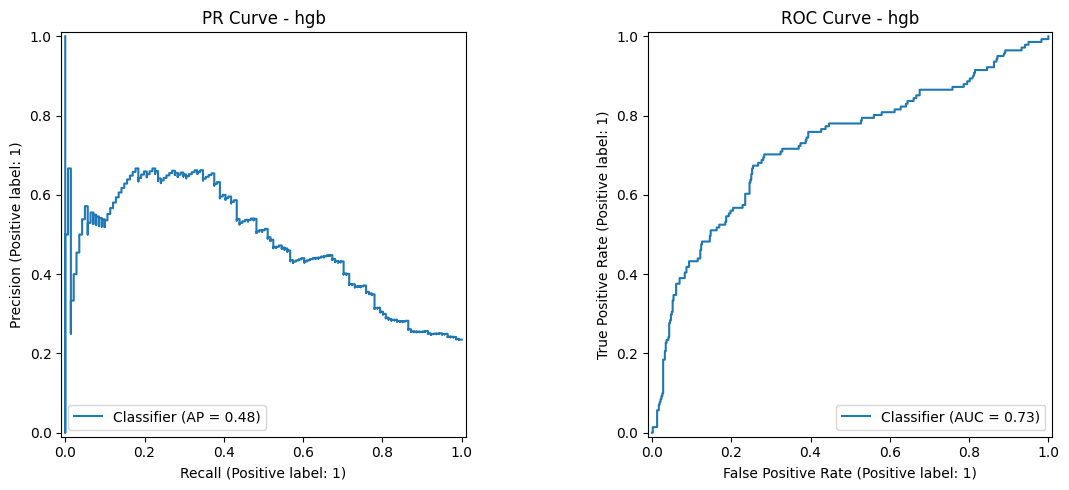

In [10]:
proba_test = champ_model.predict_proba(X_test)[:,1] # predicted probs

def find_best_threshold_youden(y_true, y_proba):
    fpr, tpr, thresholds=roc_curve(y_true, y_proba)

    # youden's J: TPR - FPR
    J = tpr - fpr

    # best threshold
    ix = np.argmax(J)
    best_threshold = thresholds[ix]

    return {
        'threshold': best_threshold,
        'youden_J': J[ix],
        'sensitivity': tpr[ix],
        'specificity': 1 - fpr[ix]
    }

result = find_best_threshold_youden(y_test, proba_test)
best_thresh = result['threshold']
y_pred = (proba_test >= best_thresh).astype(int)

print("\nConfusion Matrix @ Youden's J-opt threshold:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# curves
fig, ax = plt.subplots(1,2, figsize=(12,5))
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=ax[0])
ax[0].set_title(f'PR Curve - {champ_name}')
RocCurveDisplay.from_predictions(y_test, proba_test, ax=ax[1])
ax[1].set_title(f'ROC Curve - {champ_name}')
plt.tight_layout()
plt.show()

8. calibration
- ensures model's estimated probabilites match real-world outcomes
- ex. "among cases predicted at 0.30, about 30% actually have the event"
- critical for risk thresholds, clinical decision rules, cost-sensitive decisions, ranking quality with PR curves
- helps most when:
    - tree models
    - heavy regularization
    - class imbalance
    - when using thresholds or risk scores
- hurts most when:
    - very small dataset (isotonic overfits)
    - model already well-calibrated (sometimes log reg)

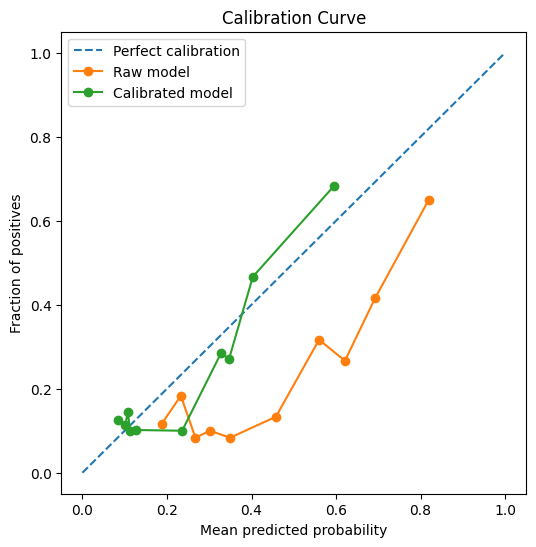

Raw Brier: 0.20390811947878995
Calibrated Brier: 0.15166433624892237


In [11]:
# split training data into 3 folds
# train champ_model on 2 folds
# predict probabilities on held-out folds
# collect out-of-fold predictions
# fit calbiration function mapping raw probs to calibrated prob
calibrated = CalibratedClassifierCV(champ_model, method='isotonic', cv=3) # isotonic = non-parametric monotonic function, flexible shape, works well with lots of data
calibrated.fit(X_train, y_train) # this helps to reduce under/over confidence

proba_cal = calibrated.predict_proba(X_test)[:,1] # note: calibration only changes probabilites, not class predictions

# calibration curves
frac_pos_raw, mean_pred_raw = calibration_curve(
    y_test, proba_test, n_bins=10, strategy="quantile"
)
frac_pos_cal, mean_pred_cal = calibration_curve(
    y_test, proba_cal, n_bins=10, strategy="quantile"
)
plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Raw model")
plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="Calibrated model")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

print("Raw Brier:", brier_score_loss(y_test, proba_test))
print("Calibrated Brier:", brier_score_loss(y_test, proba_cal)) # brier score = MSE of probs, lower is better

# calibrated brier score is lower --> calibration helps!

9. model explainability

                feature  importance
10        complications    0.117972
3     chronic_condition    0.085790
1                   age    0.019490
7   length_of_stay_days    0.008888
9      medication_count    0.004588
12         total_cost_€    0.003260
5            department    0.000000
0            patient_id    0.000000
2                gender   -0.000013
13   satisfaction_score   -0.000212
11     discharge_status   -0.000396
4        admission_type   -0.001341
8      procedures_count   -0.005641
6         wait_time_min   -0.014990


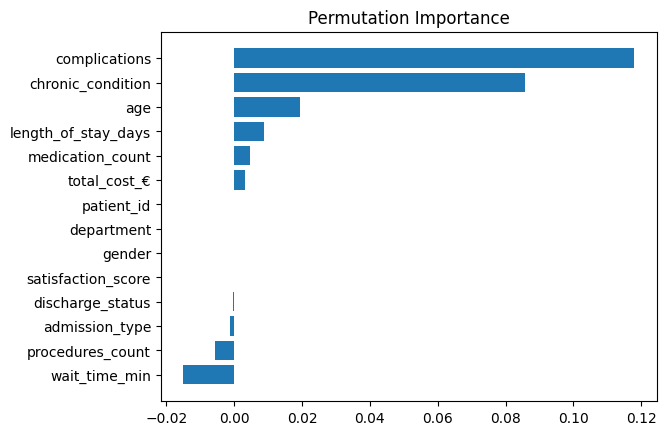

In [ ]:
# permutation importance

# measure baseline performance
# for each feature: randomly shuffle its values, recompute performance
# importance = baseline score - shuffled score
# positive --> feature helps model
# ~0 --> feature not usefule
# negative --> model performs better without it
imp = permutation_importance(
    champ_model, 
    X_test, 
    y_test, 
    n_repeats=10, 
    scoring="average_precision",
    random_state=42, 
    n_jobs=-1
)

perm = pd.DataFrame({
    "feature": X_test.columns,
    "importance": imp.importances_mean
}).sort_values("importance", ascending=False)

print(perm.head(20))

top_perm = perm.head(20).sort_values("importance")
plt.figure()
plt.barh(top_perm["feature"], top_perm["importance"])
plt.title("Permutation Importance")
plt.show()

# next step: remove features with negative importance and retrain

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 10 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 3 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Library/Framewor

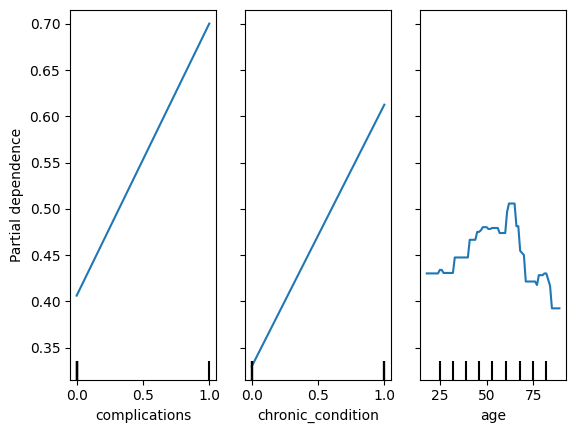

In [17]:
# partial dependence
features_to_plot = perm.head(3)["feature"].tolist()

PartialDependenceDisplay.from_estimator(
    champ_model,
    X_test,
    features_to_plot
)
plt.show()

10. persist model

In [19]:
joblib.dump(champ_model, f'model_readmission_{champ_name}.joblib')
joblib.dump(calibrated, f'model_readmission_{champ_name}.joblib')
print("Saved champion and calibrated models")

# load later
# model = joblib.load('model_readmission_{champ_name}.joblib')

Saved champion and calibrated models
